In [13]:
# imports
import numpy as np
import pandas as pd
import scipy.stats as stats

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('scifigs.mplstyle')

from dual_pfc_funcs import getParams, load_dict

# params
SAVE_FIG = False
data_path = 'preprocessed_data/'
params = getParams()
subjects, symbols = params['subjects'], params['markers']

In [10]:
alt_mdls = load_dict(data_path + 'all_alt_mdls_cv.pkl')
pccafa = {}
for sub in subjects:
    pccafa = {**pccafa, **load_dict(data_path + sub + '_pccafa_cv15dim.pkl')}

# compile into single dat with session name as key
dat = {}
for fname in pccafa.keys():
    try:
        dat[fname] = {**alt_mdls[fname], 'pccafa_LL':pccafa[fname]['cvLL']['final_LL'], 'pccafa':pccafa[fname]['params']}
    except: continue

In [11]:
# data aggregation
df = pd.DataFrame(columns=['SessionID', 'neurons_left', 'neurons_right', 'n_trials', 'NormalizationFactor',
                            'pccafa_LL', 'pcca_LL', 'jointFA_LL', 'indFA_LL', 'pcca_norm_diff', 'jointFA_norm_diff', 'indFA_norm_diff'])


for fname in dat.keys():
    # to compute normalization factor, we need the number of trials and neurons for each session
    n_left, n_right, N = dat[fname]["n_neurons_left"],dat[fname]["n_neurons_right"],dat[fname]["n_trials"]
    norm_factor = (n_left + n_right) * N

    # pCCA-FA LL:
    curr_pccafa_ll = dat[fname]['pccafa_LL']

    # alternative model LLs:
    curr_jfa_ll = np.max(dat[fname]['joint_LL'])
    curr_ifa_ll = np.max(dat[fname]['ind_fa_LH_LL']) + np.max(dat[fname]['ind_fa_RH_LL'])
    curr_pcca_ll = np.max(dat[fname]['pcca_LL'])

    # normalize LL differences:
    pcca_norm_diff = (curr_pccafa_ll - curr_pcca_ll) / norm_factor
    jointFA_norm_diff = (curr_pccafa_ll - curr_jfa_ll) / norm_factor
    indFA_norm_diff = (curr_pccafa_ll - curr_ifa_ll) / norm_factor

    df2 = {'SessionID':fname, 'neurons_left':n_left, 'neurons_right':n_right, 'n_trials':N, 'NormalizationFactor':norm_factor, 
            'pccafa_LL':curr_pccafa_ll, 'pcca_LL':curr_pcca_ll, 'jointFA_LL':curr_jfa_ll, 'indFA_LL':curr_ifa_ll,
            'pcca_norm_diff':pcca_norm_diff, 'jointFA_norm_diff':jointFA_norm_diff, 'indFA_norm_diff':indFA_norm_diff}
    df.loc[len(df)] = df2
# df

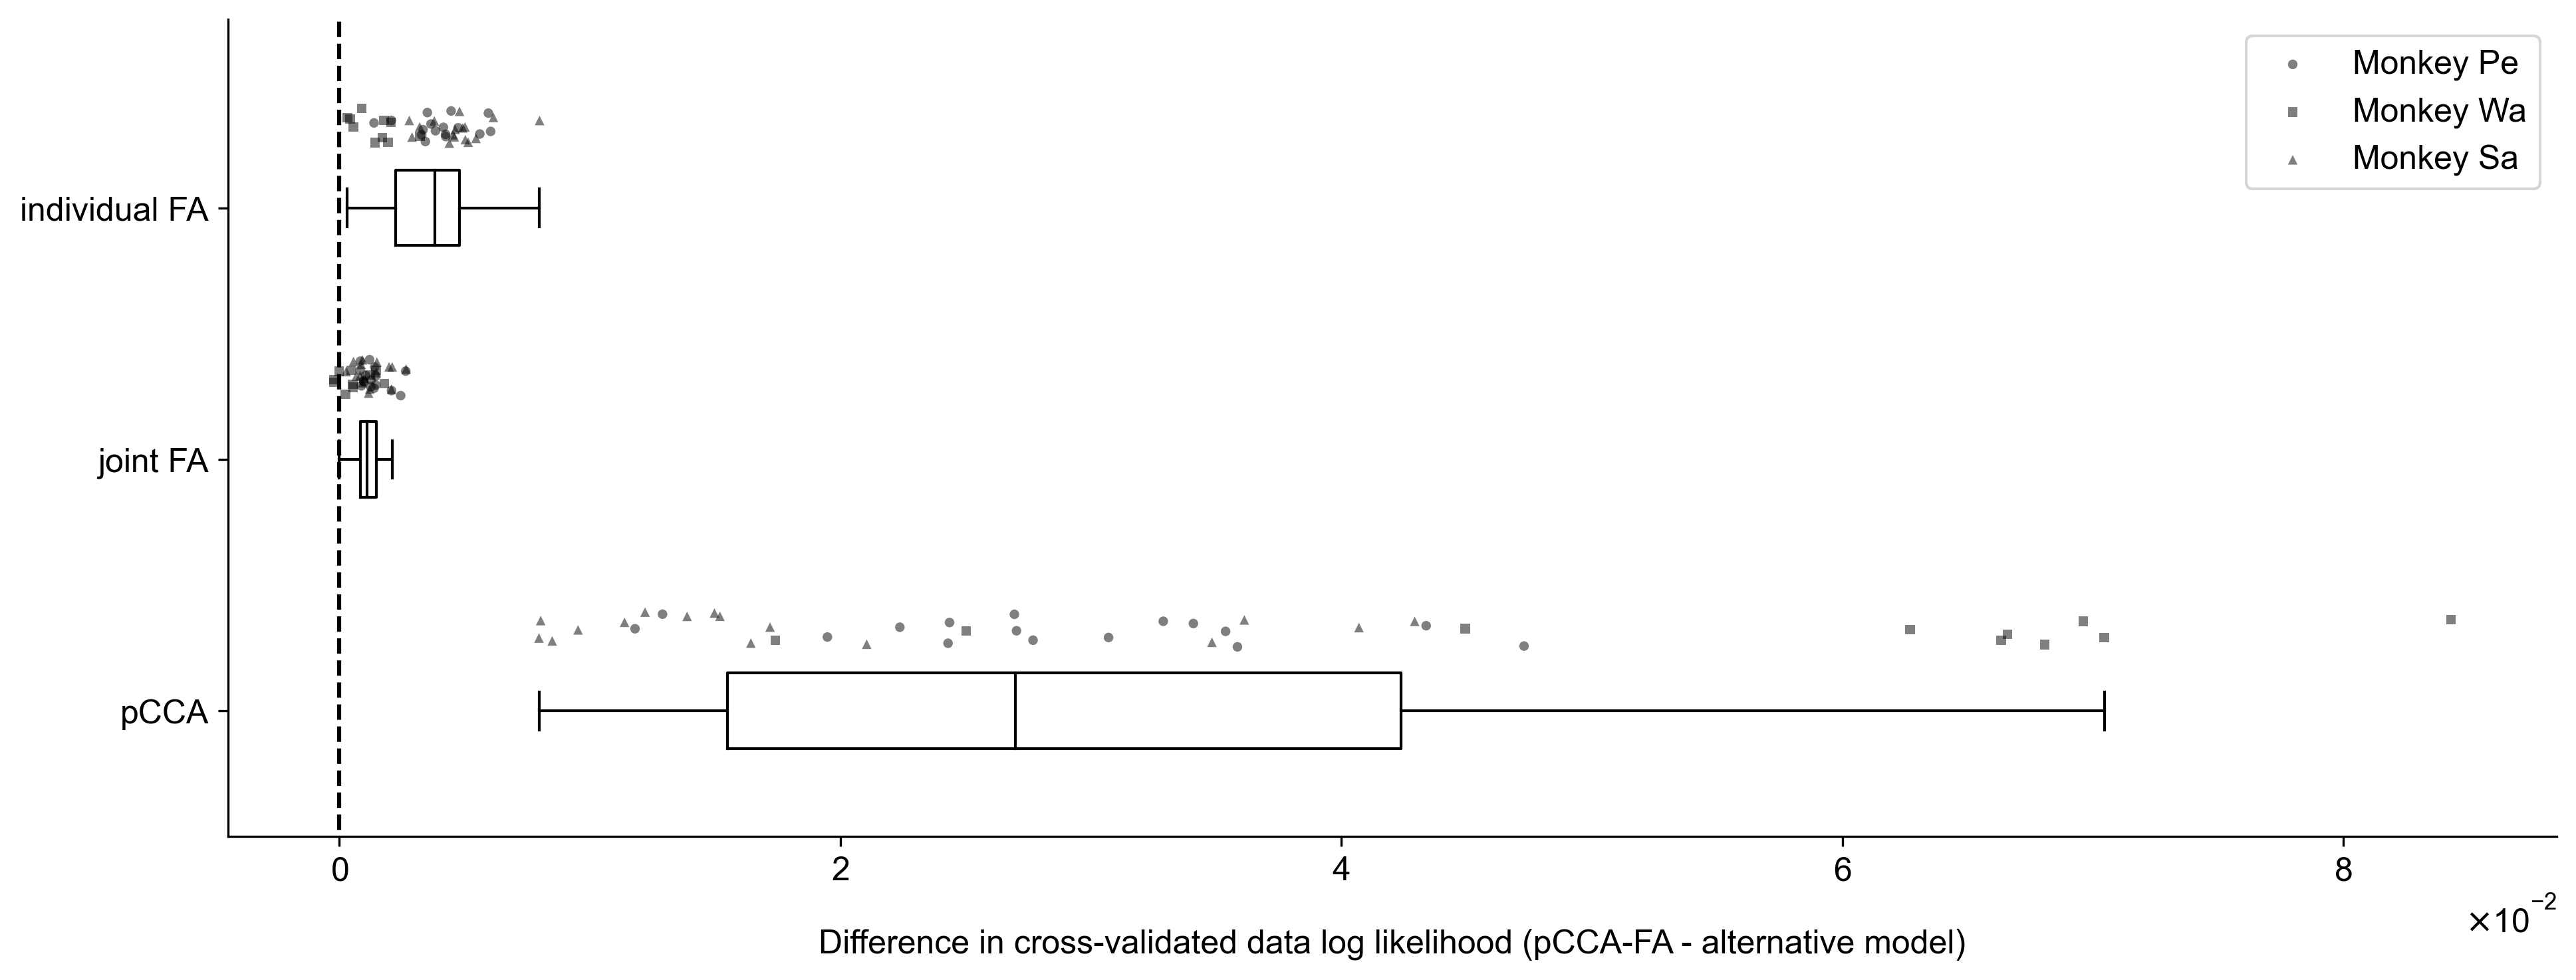

In [12]:
np.random.seed(3)

fig = plt.figure(constrained_layout=True)
fig.set_figwidth(2*fig.get_figwidth())

box = plt.boxplot(x=[df['pcca_norm_diff'],df['jointFA_norm_diff'],df['indFA_norm_diff']], vert=False, showfliers=False,
            labels=['pCCA', 'joint FA', 'individual FA'])
for _, line_list in box.items():
    for line in line_list: line.set_color('k')

plt.plot([0,0], [0,4], '--', color='k')

s = 12
for sub,sym in zip(subjects,symbols):
    filt = [sub[:2].title() in fname for fname in df['SessionID']]
    tmp_df = df[filt]

    ydata = np.random.uniform(low=1.25, high=1.4, size=len(tmp_df))
    plt.scatter(tmp_df['pcca_norm_diff'], ydata, color='black', marker=sym, alpha=0.5, s=s, zorder=10, edgecolors='none', label='Monkey {}'.format(sub[:2].title()))

    ydata = np.random.uniform(low=2.25, high=2.4, size=len(tmp_df))
    plt.scatter(tmp_df['jointFA_norm_diff'], ydata, color='black', marker=sym, alpha=0.5, s=s, zorder=10, edgecolors='none')

    ydata = np.random.uniform(low=3.25, high=3.4, size=len(tmp_df))
    plt.scatter(tmp_df['indFA_norm_diff'], ydata, color='black', marker=sym, alpha=0.5, s=s, zorder=10, edgecolors='none',)
    
plt.ticklabel_format(axis='x', style='scientific', scilimits=(-2,-2), useMathText=True)
plt.xlabel('Difference in cross-validated data log likelihood (pCCA-FA - alternative model)', labelpad=15)
plt.ylim(0.5,3.75)
plt.legend()

if SAVE_FIG:
    pdf = PdfPages('figs/alt_models.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    plt.show()

In [16]:
# statistics
alpha = 0.01 
print("Alternative model statistics across sessions:")
for sub in subjects:
    print('Monkey:', sub[:2].title())
    filt = [sub[:2].title() in fname for fname in df['SessionID']]
    tmp_df = df[filt]
    p = stats.ttest_rel(a=tmp_df['pccafa_LL'], b=tmp_df['indFA_LL'],alternative='greater').pvalue
    print("  pCCA-FA > individual FA? {}, p = {:.10f}".format(p < alpha, p))
    p = stats.ttest_rel(a=tmp_df['pccafa_LL'], b=tmp_df['jointFA_LL'],alternative='greater').pvalue
    print("  pCCA-FA > joint FA? {}, p = {:.10f}".format(p < alpha, p))
    p = stats.ttest_rel(a=tmp_df['pccafa_LL'], b=tmp_df['pcca_LL'],alternative='greater').pvalue
    print("  pCCA-FA > pCCA? {}, p = {:.10f}".format(p < alpha, p))

# quantify number of sessions > 0
print()
print("Number of sessions where pCCA-FA > ind FA: {} of {}".format(np.sum(df['indFA_norm_diff'] > 0), len(df)))
print("Number of sessions where pCCA-FA > joint FA: {} of {}".format(np.sum(df['jointFA_norm_diff'] > 0), len(df)))
print("Number of sessions where pCCA-FA > pCCA: {} of {}".format(np.sum(df['pcca_norm_diff'] > 0), len(df)))

Alternative model statistics across sessions:
Monkey: Pe
  pCCA-FA > individual FA? True, p = 0.0000000555
  pCCA-FA > joint FA? True, p = 0.0000001056
  pCCA-FA > pCCA? True, p = 0.0000000000
Monkey: Wa
  pCCA-FA > individual FA? True, p = 0.0018096258
  pCCA-FA > joint FA? False, p = 0.0139285172
  pCCA-FA > pCCA? True, p = 0.0000004476
Monkey: Sa
  pCCA-FA > individual FA? True, p = 0.0000014280
  pCCA-FA > joint FA? True, p = 0.0000006587
  pCCA-FA > pCCA? True, p = 0.0000000054

Number of sessions where pCCA-FA > ind FA: 42 of 42
Number of sessions where pCCA-FA > joint FA: 39 of 42
Number of sessions where pCCA-FA > pCCA: 42 of 42
